<a href="https://colab.research.google.com/github/RAGUL085/21ITR085/blob/main/Gastric%20cancer%20diagnosis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [32]:
# Copyright (c) Microsoft Corporation. All rights reserved.
# Licensed under the MIT License.
import pandas as pd
import numpy as np
from sklearn.linear_model import Lasso
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier as RF
from sklearn.metrics import roc_curve, roc_auc_score, f1_score
from sklearn.model_selection import train_test_split,RepeatedKFold,StratifiedShuffleSplit
%matplotlib inline
import matplotlib.pyplot as plt
from collections import Counter

In [33]:
##### settings #####
rng_seed = 42 # control reproducibility
ran_sta = 3
method = "lasso"
Counts=Counter()

In [51]:

Xtrain = pd.read_excel('Data/Xtrain.xlsx',index_col=0)
ytrain = pd.read_excel('Data/ytrain.xlsx',index_col=0)
Xtest = pd.read_excel('Data/Xtest.xlsx',index_col=0)
ytest = pd.read_excel('Data/ytest.xlsx',index_col=0)

Xtrain.drop(['sample_id'],axis=1,inplace=True)
Xtest.drop(['sample_id'],axis=1,inplace=True)

metas=list(Xtrain.columns)
ytrain = np.array(ytrain.state)
ytrain = ytrain.astype(np.float32)
ytest = np.array(ytest.state)
ytest = ytest.astype(np.float32)

Xtrain=Xtrain.values
Xtest=Xtest.values
print("train test info:")
print("train, normal-patients", np.unique(ytrain,return_counts=True))
print("test, normal-patients", np.unique(ytest,return_counts=True))

train test info:
train, normal-patients (array([0., 1.], dtype=float32), array([32, 63]))
test, normal-patients (array([0., 1.], dtype=float32), array([94, 48]))


In [52]:
def test(model, Xtest, ytest, metric='auc'):
    pred = model.predict(Xtest)
    prob = model.predict_proba(Xtest)
    print("ytest,pred:",ytest,pred)
    s = f1_score(ytest, pred)
    print("ytest,prob:",ytest,prob[:,-1])
    s1 = roc_auc_score(ytest, prob[:,-1])
    print("f1 score:", s)
    print("auroc score:", s1)
    return (s,s1)

def train_test(Xtrain, ytrain, Xtest, ytest, test_fn="RF", seed=12306, metric='auc'):
    model = RF(n_estimators=100,random_state=seed)
    model.fit(Xtrain, ytrain)
    print("evaluate on train set:")
    test(model, Xtrain, ytrain, metric)
    print("evaluate on test set:")
    s = test(model, Xtest, ytest, metric)
    return model, s

In [53]:
from model import Selection
##### Feature selection #####
discovery_set=pd.read_excel('Data/discovery_set.xlsx',index_col=0)
discovery_set['state']=discovery_set.apply(lambda a:0 if a['type']=='N' else 1,axis=1)
labels=discovery_set['type']
plasma_df=discovery_set.copy()
batch1=plasma_df[(plasma_df['batch']=='batch1')]
batch1.reset_index(drop=True,inplace=True)
batch2=plasma_df[(plasma_df['batch']=='batch2')]
batch2.reset_index(drop=True,inplace=True)
batch3=plasma_df[plasma_df['batch']=='batch3']
batch3.reset_index(drop=True,inplace=True)

for i in range(0,10000):
    print("This is round %d"%(i))
    random_state=i
    split=StratifiedShuffleSplit(n_splits=1, test_size=0.33, random_state=random_state)
    for train_index, test_index in split.split(batch1,batch1['type']):
        batch1_train_set=batch1.loc[train_index]
        batch1_test_set=batch1.loc[test_index] #batch1
    for train_index, test_index in split.split(batch2,batch2['type']):
        batch2_train_set=batch2.loc[train_index]
        batch2_test_set=batch2.loc[test_index] #batch2
    for train_index, test_index in split.split(batch3,batch3['type']):
        batch3_train_set=batch3.loc[train_index]
        batch3_test_set=batch3.loc[test_index] #batch3

    # 合并3个batch的training set 和testing set数据
    Xtrain_stratified=pd.concat([batch1_train_set,batch2_train_set,batch3_train_set],axis=0)
    Xtrain_stratified.reset_index(drop=True,inplace=True)
    Xtest_stratified=pd.concat([batch1_test_set,batch2_test_set,batch3_test_set],axis=0)
    Xtest_stratified.reset_index(drop=True,inplace=True)

    # 分类数据
    ytrain_stratified=Xtrain_stratified['state']
    ytest_stratified=Xtest_stratified['state']
    # 丢弃不需要的列
    Xtrain_stratified.drop(['Batch','type','batch','state'],axis=1,inplace=True)
    Xtest_stratified.drop(['Batch','type','batch','state'],axis=1,inplace=True)

    Xtrain=Xtrain_stratified
    Xtest=Xtest_stratified
    ytrain=pd.DataFrame(ytrain_stratified)
    ytest=pd.DataFrame(ytest_stratified)

    Xtrain.drop(['sample_id'],axis=1,inplace=True)
    Xtest.drop(['sample_id'],axis=1,inplace=True)

    metas=list(Xtrain.columns)
    ytrain = np.array(ytrain.state)
    ytrain = ytrain.astype(np.float32)
    ytest = np.array(ytest.state)
    ytest = ytest.astype(np.float32)

    Xtrain=Xtrain.values
    Xtest=Xtest.values
    class ArgsClass:
        def __init__(self, k=5, alpha=0.05):
            self.k=k
            self.alpha=alpha
    args=ArgsClass(k=10, alpha=0.005)
    sel = Selection(method, args)
    sel.fit(Xtrain, ytrain)  # select on whole training set
    mb = sel.mb_
    #print("selected feature index: ", mb)
    #print("selected meta names: ", [metas[x] for x in mb])
    #print("with selected featues:")
    Counts=Counter(mb)+Counts

##### select top rank features #####
Counts_metas = pd.DataFrame(Counts.most_common(),columns=['metas_index',"counts"])
Counts_metas['metas'] = Counts_metas.apply(lambda a:metas[a['metas_index']],axis=1)
# 'Glycerate-2P_Glycerate-3P_neg-006','Citraconic acid_neg-025','Pyridoxine_pos-137','Argininosuccinic acid_pos-039'
# The above metabolites are excluded as characteristics due to poor peak shapes in mass spectrometry
Counts_metas_selected=Counts_metas[~Counts_metas['metas'].isin(['Glycerate-2P_Glycerate-3P_neg-006','Citraconic acid_neg-025','Pyridoxine_pos-137','Argininosuccinic acid_pos-039'])]
Counts_metas_selected.reset_index(drop=True,inplace=True)
Counts_metas=Counts_metas_selected
selected_feature_index=list(Counts_metas['metas_index'][0:10])

Streaming output truncated to the last 5000 lines.
self.mb_: [ 53  59  78  88 111 113 118 132 137 140]
Over max_features [ 53  59  78  88 111 113 118 132 137 140]
This is round 8334
self.mb_: [ 14  33  43  44  78 104 111 113 137 140]
Over max_features [ 14  33  43  44  78 104 111 113 137 140]
This is round 8335
self.mb_: [  4  31  44  59 111 113 115 132 137 140]
Over max_features [  4  31  44  59 111 113 115 132 137 140]
This is round 8336
self.mb_: [ 14  76  79 111 113 132 133 137 138 140]
Over max_features [ 14  76  79 111 113 132 133 137 138 140]
This is round 8337
self.mb_: [ 26  78  80  88 111 113 133 136 137 140]
Over max_features [ 26  78  80  88 111 113 133 136 137 140]
This is round 8338
self.mb_: [  7  44  78  88 113 132 133 134 137 140]
Over max_features [  7  44  78  88 113 132 133 134 137 140]
This is round 8339
self.mb_: [  0   4  54  59 111 113 133 137 139 140]
Over max_features [  0   4  54  59 111 113 133 137 139 140]
This is round 8340
self.mb_: [ 14  48  79  87 111 1

In [54]:
# Train a random forest model using the selected features.
s=[]
s1=[]
model = RF(n_estimators=100,random_state=12306)
model.fit(Xtrain[:,Counts_metas['metas_index'][0:10]], ytrain)
pred = model.predict(Xtest[:,Counts_metas['metas_index'][0:10]])
prob = model.predict_proba(Xtest[:,Counts_metas['metas_index'][0:10]])
print("ytest,pred:",ytest,pred)
s.append(f1_score(ytest, pred))
print("ytest,prob:",ytest,prob[:,-1])
s1.append(roc_auc_score(ytest, prob[:,-1]))
print("f1 score:", s)
print("auroc score:", s1)

ytest,pred: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 1. 0. 0. 0.
 0. 0. 0. 0. 1. 0. 1. 0. 1. 0. 0. 0. 0. 1. 0. 1. 0. 1. 1. 1. 0. 0. 0. 1.
 0. 0. 0. 0. 1. 0. 1. 1. 0. 0. 0. 0. 0. 1. 0. 0. 1. 1. 0. 1. 1. 0. 0. 1.
 1. 0. 1. 1. 1. 1. 0. 1. 1. 0. 1. 0. 1. 1. 0. 1. 1. 1. 0. 1. 1. 0. 1. 0.
 0. 1. 0. 0. 1. 0. 1. 1. 1. 0. 0. 0. 0. 1. 1. 0. 1. 1. 1. 1. 1. 0.] [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 0. 0. 1. 0. 0. 0.
 0. 1. 0. 0. 1. 0. 1. 0. 0. 0. 1. 0. 0. 1. 0. 1. 0. 1. 1. 0. 0. 0. 0. 1.
 0. 0. 0. 0. 1. 0. 1. 1. 0. 0. 0. 0. 0. 1. 0. 0. 1. 1. 0. 1. 1. 0. 0. 1.
 1. 0. 1. 1. 0. 1. 0. 1. 0. 0. 1. 0. 1. 1. 0. 1. 1. 1. 0. 1. 1. 0. 1. 0.
 0. 1. 0. 0. 1. 1. 1. 0. 1. 0. 0. 0. 0. 1. 1. 1. 1. 0. 1. 1. 1. 0.]
ytest,prob: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 

In [55]:
n_bootstraps = 1000
def CI(y_true, y_pred):
    bootstrapped_scores = []
    print("auroc score:", roc_auc_score(y_true, y_pred))
    rng = np.random.RandomState(rng_seed)
    for i in range(n_bootstraps):
        # bootstrap by sampling with replacement on the prediction indices
        indices = rng.randint(0, len(y_pred), len(y_pred))
        if len(np.unique(y_true[indices])) < 2:
            # We need at least one positive and one negative sample for ROC AUC
            # to be defined: reject the sample
            continue

        score = roc_auc_score(y_true[indices], y_pred[indices])
        bootstrapped_scores.append(score)
        #print("Bootstrap #{} ROC area: {:0.3f}".format(i + 1, score))
    sorted_scores = np.array(bootstrapped_scores)
    sorted_scores.sort()

    # Computing the lower and upper bound of the 90% confidence interval
    # You can change the bounds percentiles to 0.025 and 0.975 to get
    # a 95% confidence interval instead.
    confidence_lower = sorted_scores[int(0.05 * len(sorted_scores))]
    confidence_upper = sorted_scores[int(0.95 * len(sorted_scores))]
    print("Confidence interval for the score: [{:0.3f} - {:0.3}]".format(
        confidence_lower, confidence_upper))
    return confidence_lower, confidence_upper

auroc score: 0.9787234042553191
Confidence interval for the score: [0.962 - 0.993]


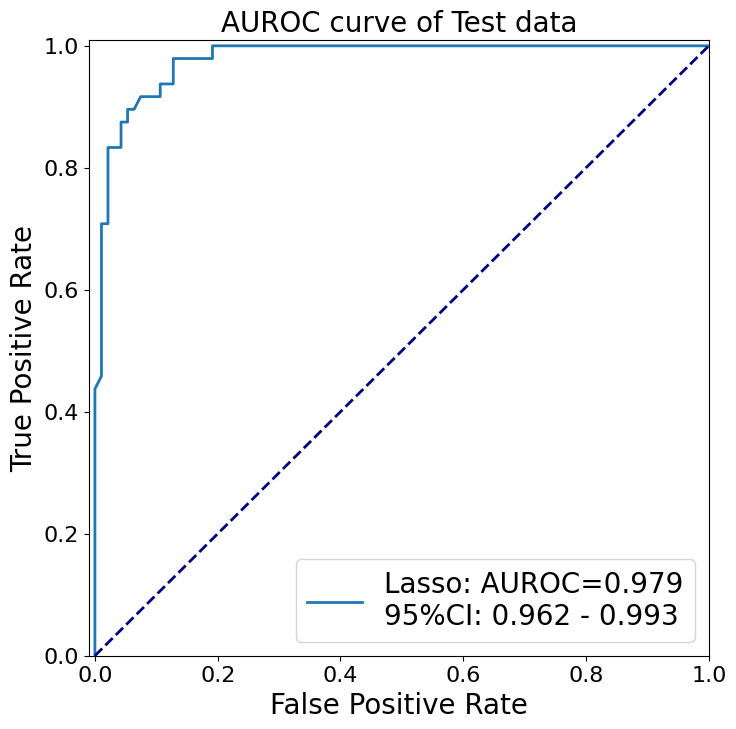

In [56]:
# Draw the AUROC curve for the test dataset
y_pred=prob[:,-1]
plt.figure(figsize=(8, 8))
exp_to_run='AUROC curve of Test data'
fpr, tpr, _ = roc_curve(ytest, y_pred)
r , l = CI(ytest, y_pred)
raw=roc_auc_score(ytest,y_pred)
tex = 'Lasso: AUROC={:0.3f}\n95%CI: {:0.3f} - {:0.3f}'.format(raw,r,l)
plt.plot(fpr, tpr, lw=2, label=tex)

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([-0.01, 1.0])
plt.ylim([0.0, 1.01])
plt.xlabel('False Positive Rate', fontdict={'size'   : 20})
plt.ylabel('True Positive Rate', fontdict={'size'   : 20})
plt.title(exp_to_run, fontdict={'size'   : 20})
plt.yticks(size = 16)
plt.xticks(size = 16)
plt.legend(loc="lower right",fontsize=20)
plt.savefig("Data/{}_roc.pdf".format("Test"))
plt.show()

In [57]:
imp=model.feature_importances_
feature_importances=pd.concat([pd.DataFrame(Counts_metas['metas'][0:10]),pd.DataFrame(imp)],axis=1)
feature_importances.columns=['feature_name','importance_score']
feature_importances

,feature_name,importance_score
0,Succinate_neg-079,0.261896
1,Fumaric acid_neg-036,0.067519
2,Uridine_neg-088,0.170544
3,Pyroglutamic acid_neg-072,0.105982
4,Citrate_neg-026,0.089167
5,S-Adenosyl-methionine_pos-139,0.094654
6,Lysine_pos-105,0.041704
7,2-Aminooctanoic acid_pos-006,0.071296
8,Hypoxanthine_pos-096,0.050900
9,GSH_pos-085,0.046336


In [58]:
!pip install matplotlib seaborn reportlab
!pip install xgboost
!pip install lightgbm
!pip install catboost

[LightGBM] [Info] Number of positive: 97, number of negative: 187
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000109 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 950
[LightGBM] [Info] Number of data points in the train set: 284, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.341549 -> initscore=-0.656398
[LightGBM] [Info] Start training from score -0.656398
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

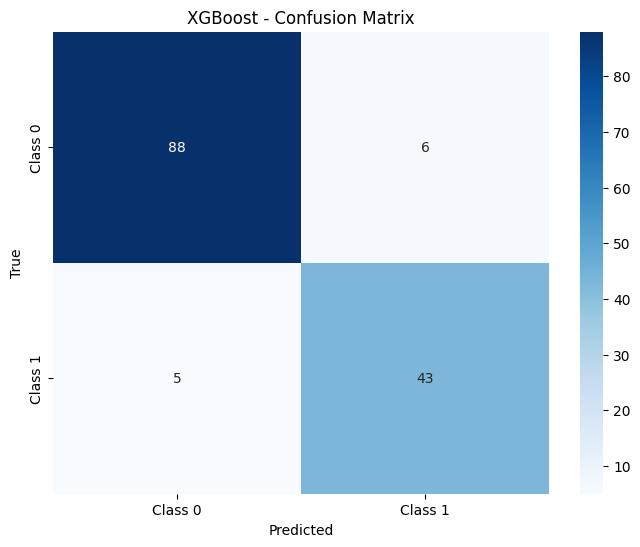

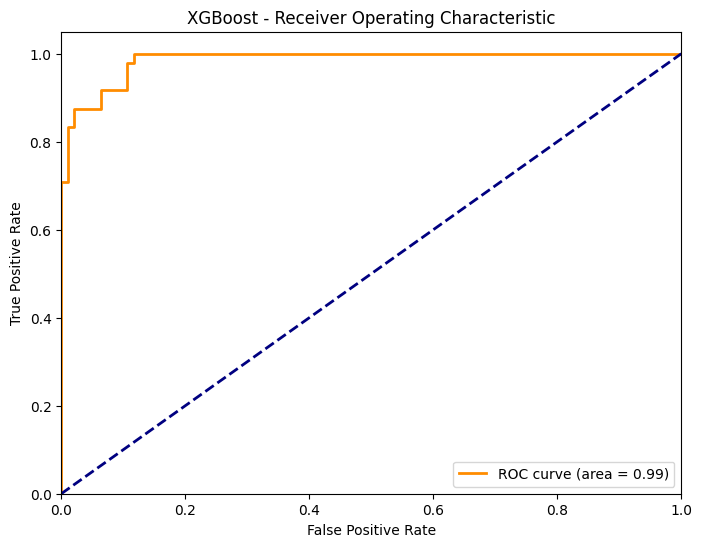

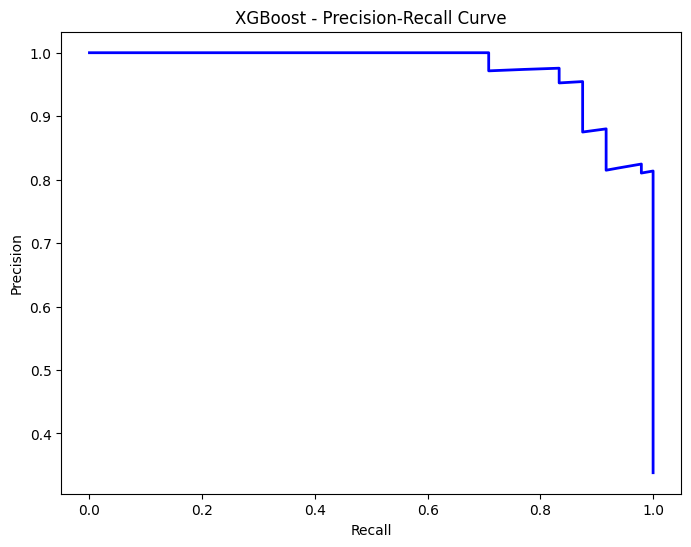




LightGBM - Accuracy: 0.9437
LightGBM - Precision: 0.9167
LightGBM - Recall: 0.9167
LightGBM - F1 Score: 0.9167
LightGBM - AUROC Score: 0.9869
LightGBM - AUROC Confidence Interval: [0.9748 - 0.9966]
LightGBM - Confusion Matrix:
[[90  4]
 [ 4 44]]
LightGBM - Classification Report:
              precision    recall  f1-score   support

         0.0       0.96      0.96      0.96        94
         1.0       0.92      0.92      0.92        48

    accuracy                           0.94       142
   macro avg       0.94      0.94      0.94       142
weighted avg       0.94      0.94      0.94       142






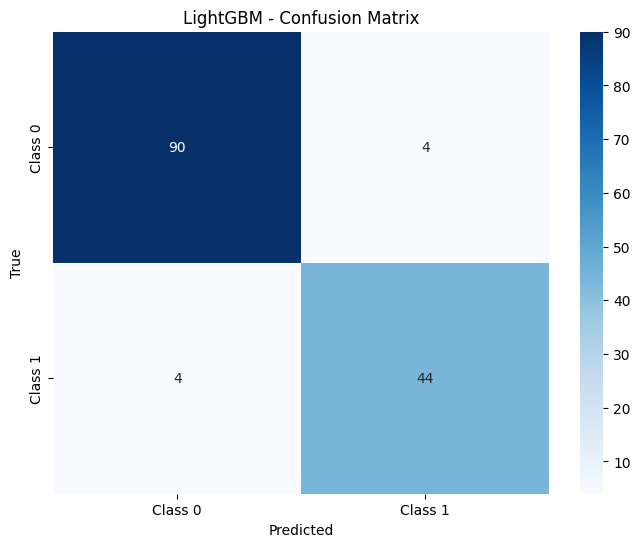

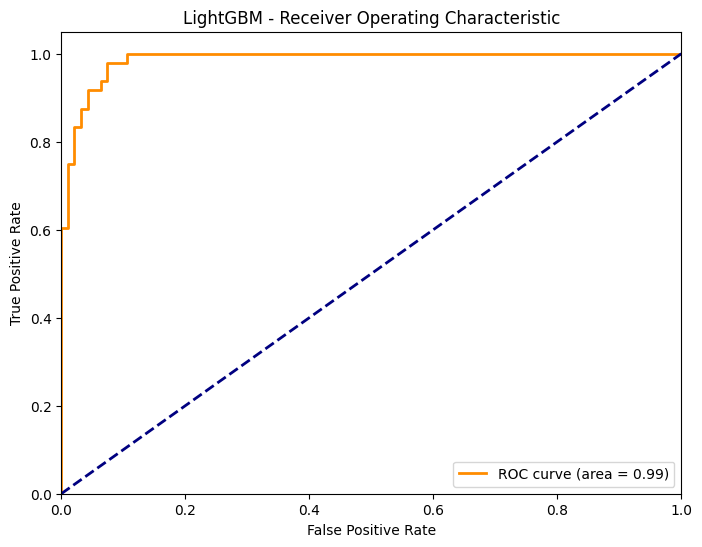

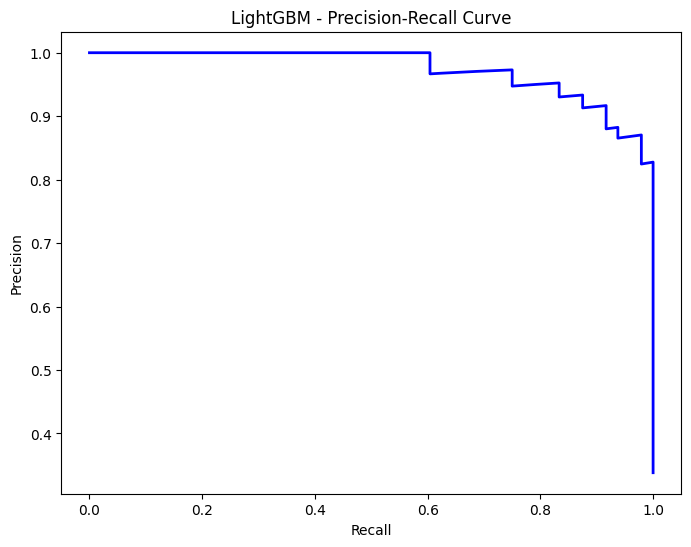




CatBoost - Accuracy: 0.9225
CatBoost - Precision: 0.8776
CatBoost - Recall: 0.8958
CatBoost - F1 Score: 0.8866
CatBoost - AUROC Score: 0.9798
CatBoost - AUROC Confidence Interval: [0.9634 - 0.9937]
CatBoost - Confusion Matrix:
[[88  6]
 [ 5 43]]
CatBoost - Classification Report:
              precision    recall  f1-score   support

         0.0       0.95      0.94      0.94        94
         1.0       0.88      0.90      0.89        48

    accuracy                           0.92       142
   macro avg       0.91      0.92      0.91       142
weighted avg       0.92      0.92      0.92       142






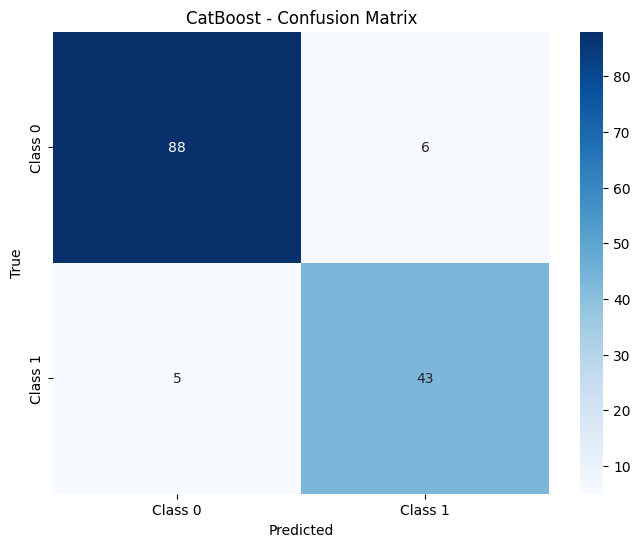

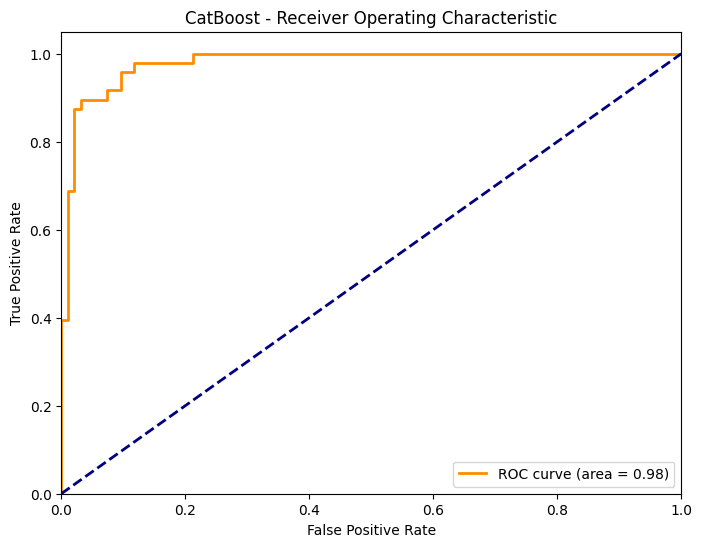

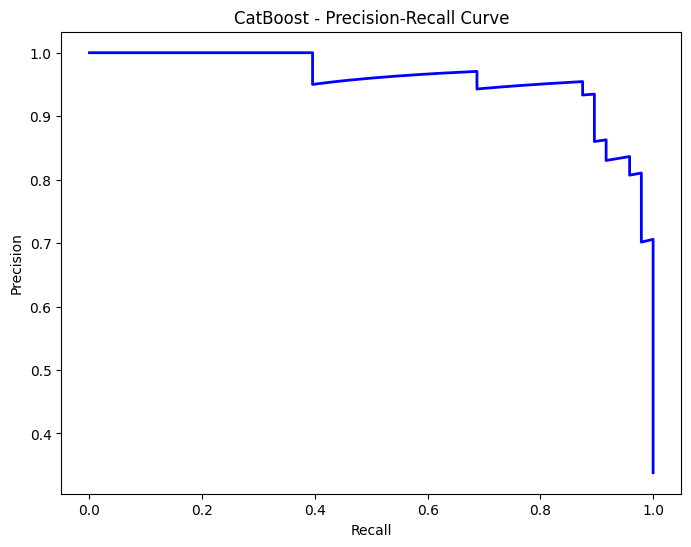

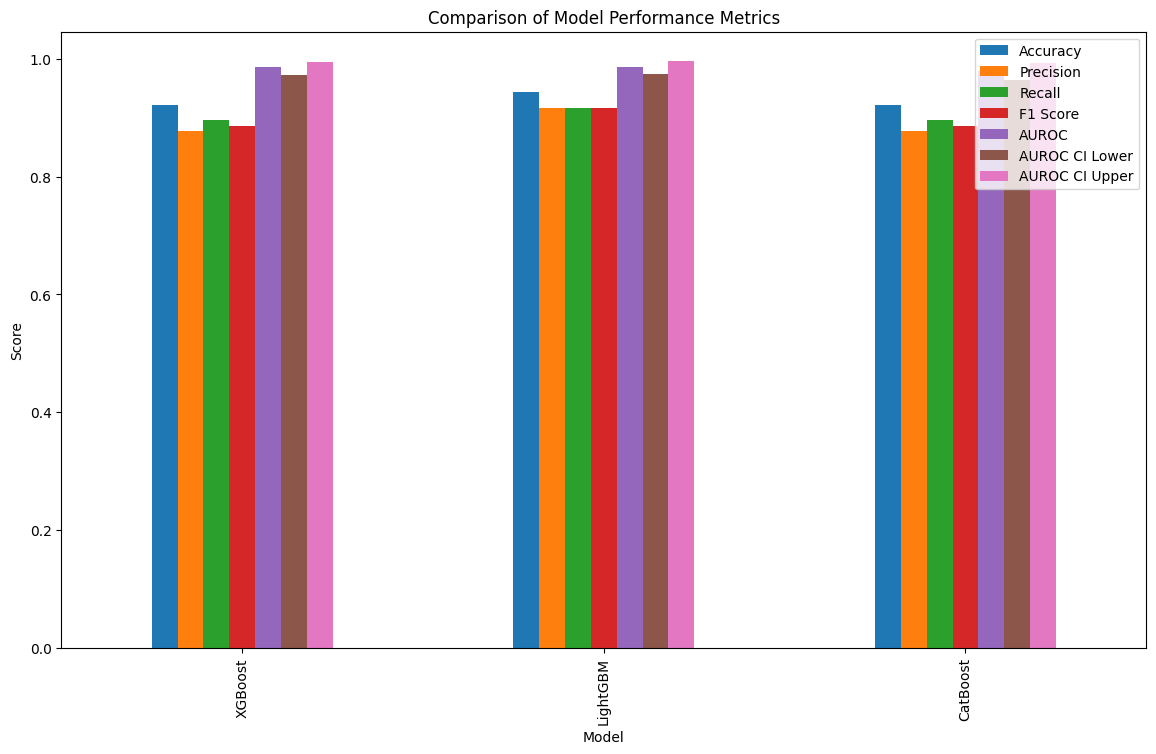

In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, roc_curve, auc,
                             precision_recall_curve)

# Set parameters
n_bootstraps = 1000
rng_seed = 42

def CI(y_true, y_pred, n_bootstraps=n_bootstraps, rng_seed=rng_seed):
    """Calculate confidence interval for ROC AUC score using bootstrapping."""
    bootstrapped_scores = []
    rng = np.random.RandomState(rng_seed)
    for _ in range(n_bootstraps):
        indices = rng.randint(0, len(y_pred), len(y_pred))
        if len(np.unique(y_true[indices])) < 2:
            continue
        score = roc_auc_score(y_true[indices], y_pred[indices])
        bootstrapped_scores.append(score)

    sorted_scores = np.array(bootstrapped_scores)
    sorted_scores.sort()

    confidence_lower = sorted_scores[int(0.05 * len(sorted_scores))]
    confidence_upper = sorted_scores[int(0.95 * len(sorted_scores))]
    return confidence_lower, confidence_upper

# Initialize models
xgb_model = XGBClassifier(n_estimators=100, random_state=10306)
lgbm_model = LGBMClassifier(n_estimators=100, random_state=12300)
catboost_model = CatBoostClassifier(n_estimators=100, random_state=12300, verbose=0)

# Train each model
xgb_model.fit(Xtrain[:, Counts_metas['metas_index'][0:10]], ytrain)
lgbm_model.fit(Xtrain[:, Counts_metas['metas_index'][0:10]], ytrain)
catboost_model.fit(Xtrain[:, Counts_metas['metas_index'][0:10]], ytrain)

# Prepare to store metrics
metrics = {
    "Model": [],
    "Accuracy": [],
    "Precision": [],
    "Recall": [],
    "F1 Score": [],
    "AUROC": [],
    "AUROC CI Lower": [],
    "AUROC CI Upper": []
}

# Predict and evaluate performance
for model, name in [(xgb_model, "XGBoost"), (lgbm_model, "LightGBM"), (catboost_model, "CatBoost")]:
    pred = model.predict(Xtest[:, Counts_metas['metas_index'][0:10]])
    prob = model.predict_proba(Xtest[:, Counts_metas['metas_index'][0:10]])[:, -1]

    # Calculate metrics
    accuracy = accuracy_score(ytest, pred)
    precision = precision_score(ytest, pred)
    recall = recall_score(ytest, pred)
    f1 = f1_score(ytest, pred)
    auroc = roc_auc_score(ytest, prob)

    # Confidence intervals for ROC AUC
    auroc_ci_lower, auroc_ci_upper = CI(ytest, prob)

    # Store metrics
    metrics["Model"].append(name)
    metrics["Accuracy"].append(accuracy)
    metrics["Precision"].append(precision)
    metrics["Recall"].append(recall)
    metrics["F1 Score"].append(f1)
    metrics["AUROC"].append(auroc)
    metrics["AUROC CI Lower"].append(auroc_ci_lower)
    metrics["AUROC CI Upper"].append(auroc_ci_upper)
    print("\n\n")
    # Print metrics
    print(f"{name} - Accuracy: {accuracy:.4f}")
    print(f"{name} - Precision: {precision:.4f}")
    print(f"{name} - Recall: {recall:.4f}")
    print(f"{name} - F1 Score: {f1:.4f}")
    print(f"{name} - AUROC Score: {auroc:.4f}")
    print(f"{name} - AUROC Confidence Interval: [{auroc_ci_lower:.4f} - {auroc_ci_upper:.4f}]")
    print(f"{name} - Confusion Matrix:\n{confusion_matrix(ytest, pred)}")
    print(f"{name} - Classification Report:\n{classification_report(ytest, pred)}")
    print("\n\n")
    # Plot confusion matrix
    conf_matrix = confusion_matrix(ytest, pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
    plt.title(f'{name} - Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.savefig(f'{name}_confusion_matrix.png')
    plt.show()
    print("\n\n")

    # Plot ROC curve
    fpr, tpr, _ = roc_curve(ytest, prob)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'{name} - Receiver Operating Characteristic')
    plt.legend(loc='lower right')
    plt.savefig(f'{name}_roc_curve.png')
    plt.show()
    print("\n\n")
    # Plot Precision-Recall curve
    precision_vals, recall_vals, _ = precision_recall_curve(ytest, prob)
    plt.figure(figsize=(8, 6))
    plt.plot(recall_vals, precision_vals, color='blue', lw=2)
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'{name} - Precision-Recall Curve')
    plt.savefig(f'{name}_precision_recall_curve.png')
    plt.show()

# Create comparison chart

metrics_df = pd.DataFrame(metrics)
metrics_df.set_index('Model', inplace=True)
metrics_df.plot(kind='bar', figsize=(14, 8))
plt.title('Comparison of Model Performance Metrics')
plt.ylabel('Score')
plt.xlabel('Model')
plt.legend(loc='best')
plt.savefig('model_comparison.png')
plt.show()


[LightGBM] [Info] Number of positive: 97, number of negative: 187
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000087 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 950
[LightGBM] [Info] Number of data points in the train set: 284, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.341549 -> initscore=-0.656398
[LightGBM] [Info] Start training from score -0.656398
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

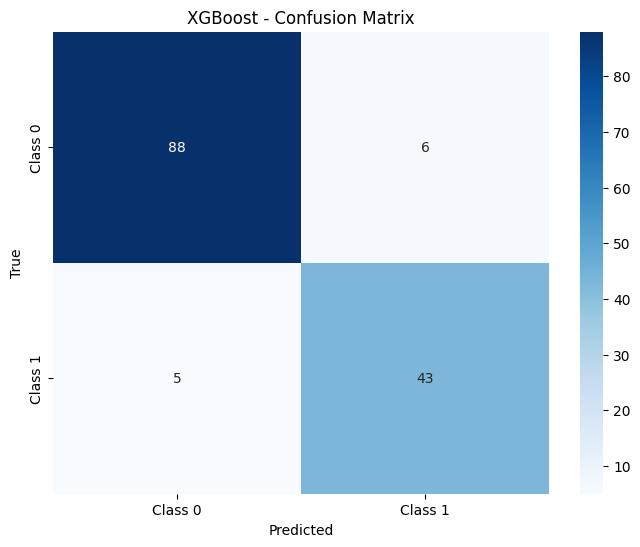

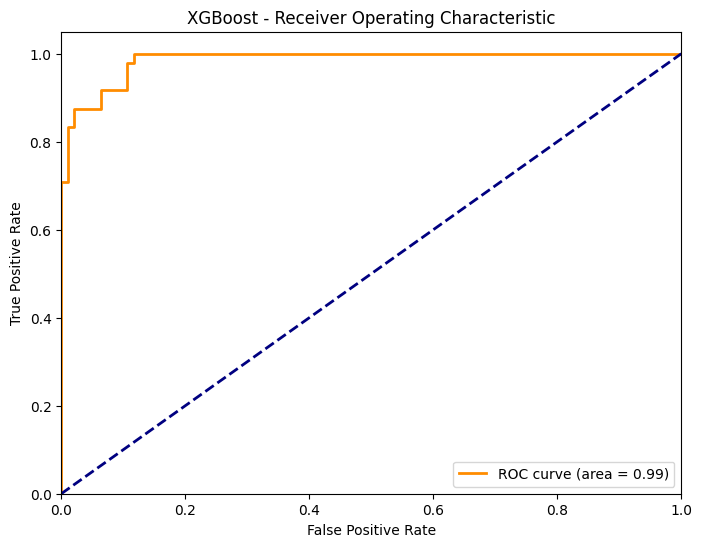

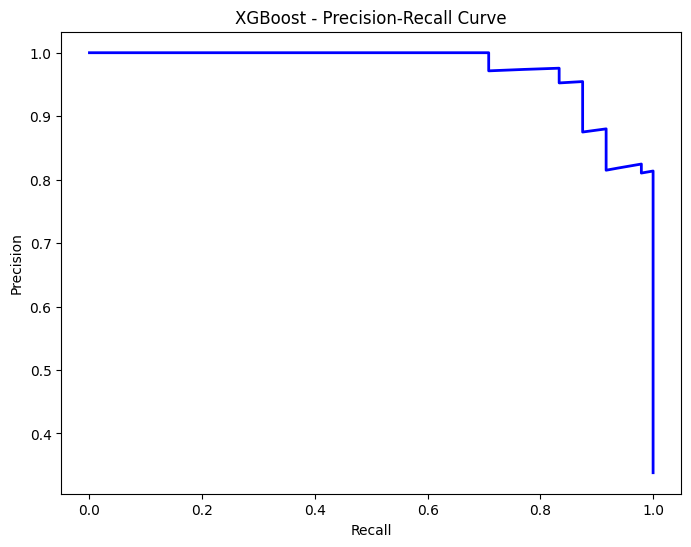




LightGBM - Accuracy: 0.9437
LightGBM - Precision: 0.9167
LightGBM - Recall: 0.9167
LightGBM - F1 Score: 0.9167
LightGBM - AUROC Score: 0.9869
LightGBM - AUROC Confidence Interval: [0.9748 - 0.9966]
LightGBM - Confusion Matrix:
[[90  4]
 [ 4 44]]
LightGBM - Classification Report:
              precision    recall  f1-score   support

         0.0       0.96      0.96      0.96        94
         1.0       0.92      0.92      0.92        48

    accuracy                           0.94       142
   macro avg       0.94      0.94      0.94       142
weighted avg       0.94      0.94      0.94       142






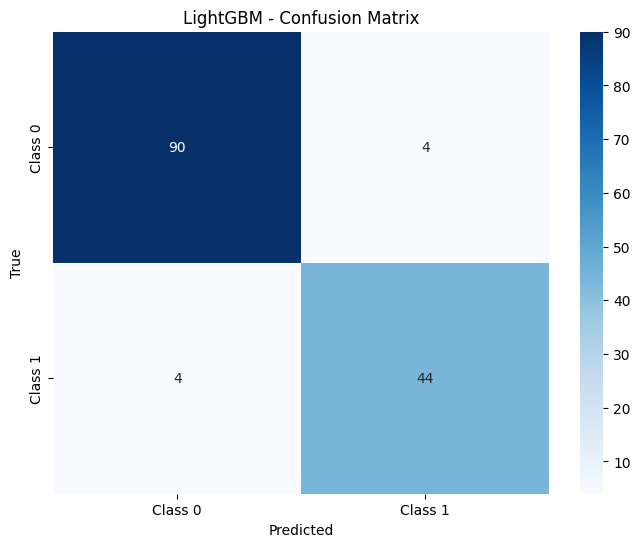

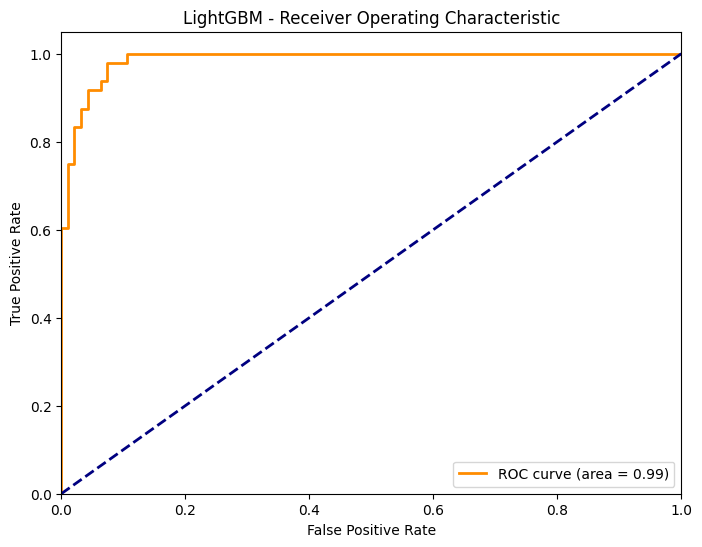

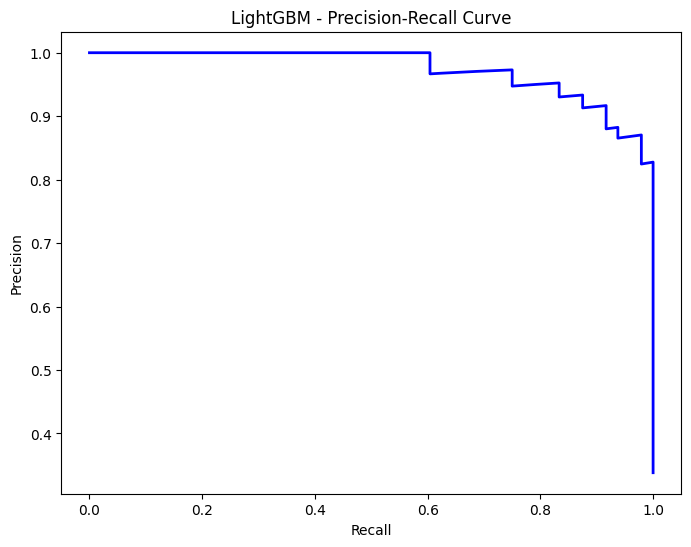




CatBoost - Accuracy: 0.9225
CatBoost - Precision: 0.8776
CatBoost - Recall: 0.8958
CatBoost - F1 Score: 0.8866
CatBoost - AUROC Score: 0.9798
CatBoost - AUROC Confidence Interval: [0.9634 - 0.9937]
CatBoost - Confusion Matrix:
[[88  6]
 [ 5 43]]
CatBoost - Classification Report:
              precision    recall  f1-score   support

         0.0       0.95      0.94      0.94        94
         1.0       0.88      0.90      0.89        48

    accuracy                           0.92       142
   macro avg       0.91      0.92      0.91       142
weighted avg       0.92      0.92      0.92       142






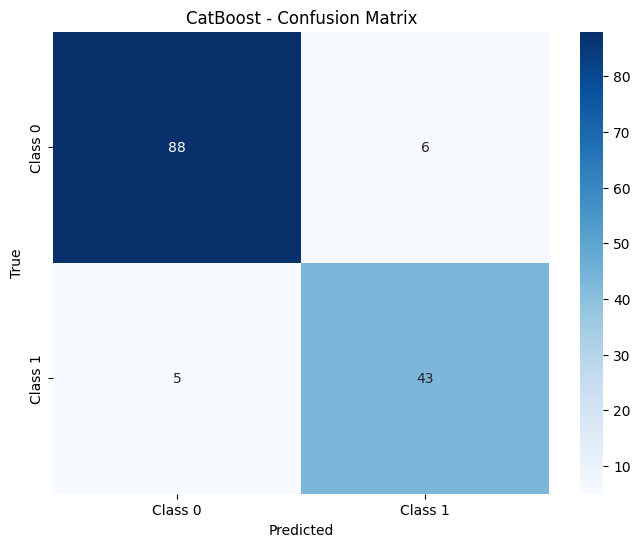

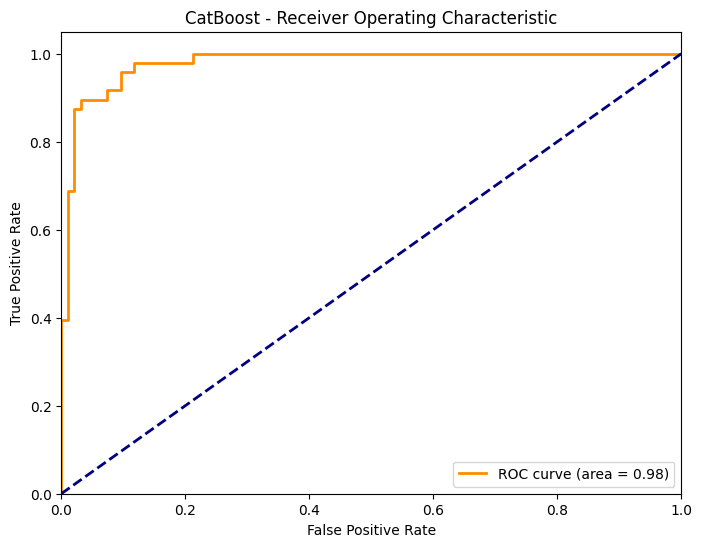

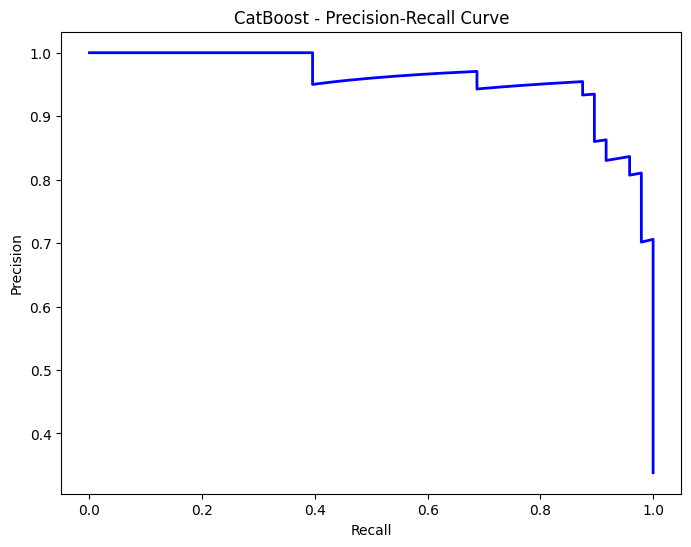

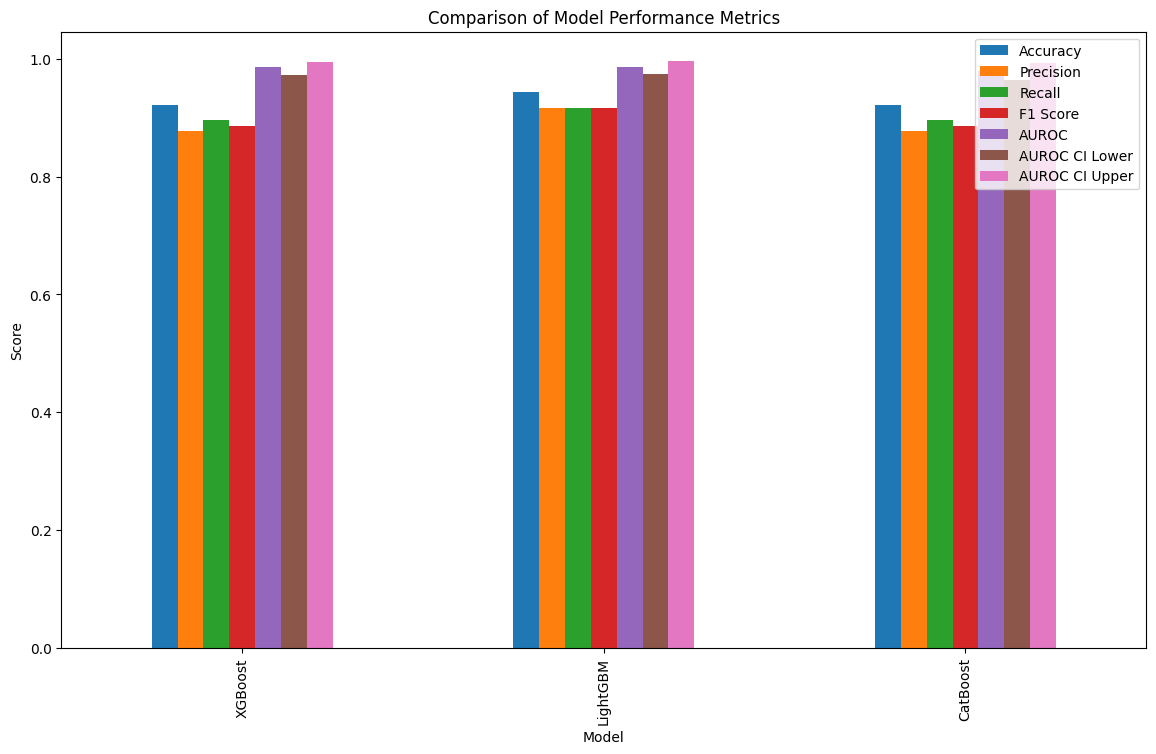

External test, normal-patients: (array([0., 1.], dtype=float32), array([187,  97]))


XGBoost - External Test Accuracy: 0.9683
XGBoost - External Test Precision: 0.9490
XGBoost - External Test Recall: 0.9588
XGBoost - External Test F1 Score: 0.9538
XGBoost - External Test AUROC Score: 0.9975
XGBoost - External Test AUROC Confidence Interval: [0.9947 - 0.9994]
XGBoost - External Test Confusion Matrix:
[[182   5]
 [  4  93]]
XGBoost - External Test Classification Report:
              precision    recall  f1-score   support

         0.0       0.98      0.97      0.98       187
         1.0       0.95      0.96      0.95        97

    accuracy                           0.97       284
   macro avg       0.96      0.97      0.96       284
weighted avg       0.97      0.97      0.97       284






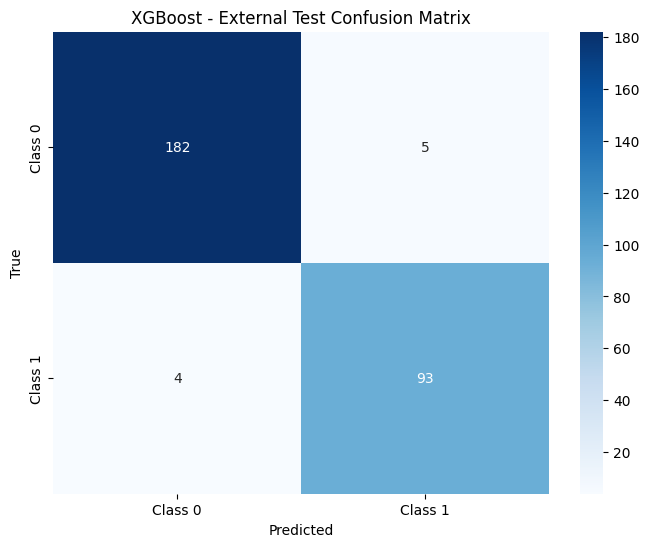

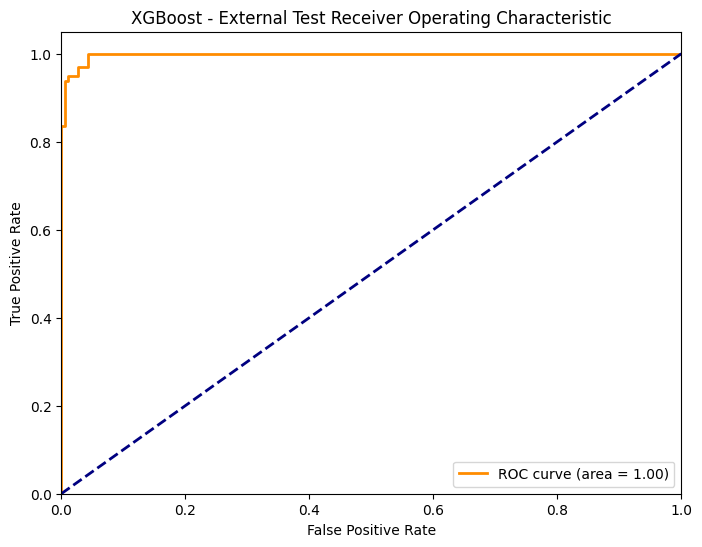

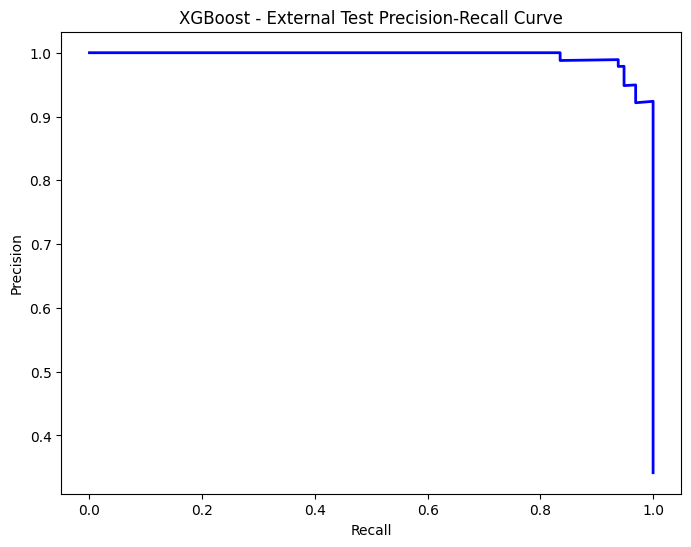



LightGBM - External Test Accuracy: 0.9789
LightGBM - External Test Precision: 0.9596
LightGBM - External Test Recall: 0.9794
LightGBM - External Test F1 Score: 0.9694
LightGBM - External Test AUROC Score: 0.9971
LightGBM - External Test AUROC Confidence Interval: [0.9933 - 0.9996]
LightGBM - External Test Confusion Matrix:
[[183   4]
 [  2  95]]
LightGBM - External Test Classification Report:
              precision    recall  f1-score   support

         0.0       0.99      0.98      0.98       187
         1.0       0.96      0.98      0.97        97

    accuracy                           0.98       284
   macro avg       0.97      0.98      0.98       284
weighted avg       0.98      0.98      0.98       284






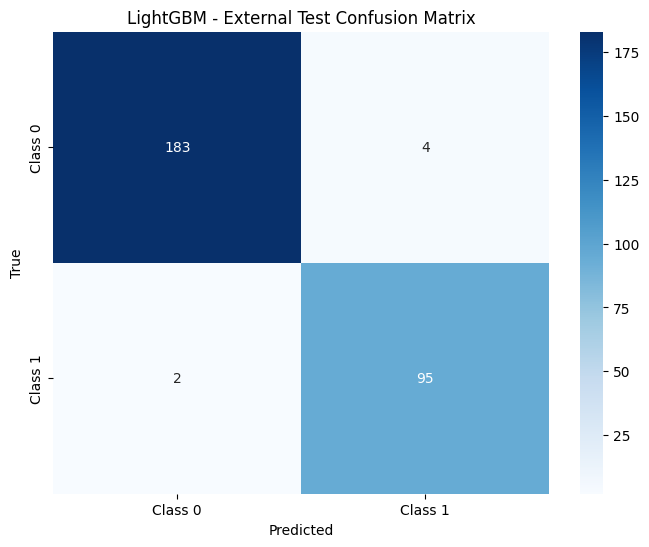

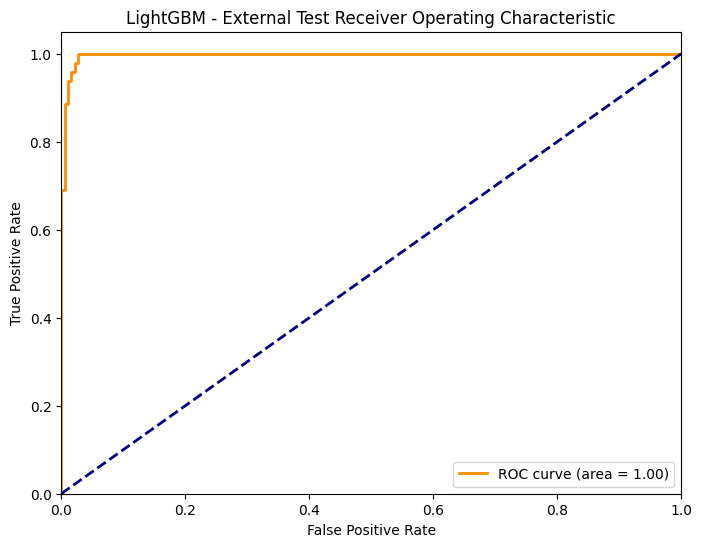

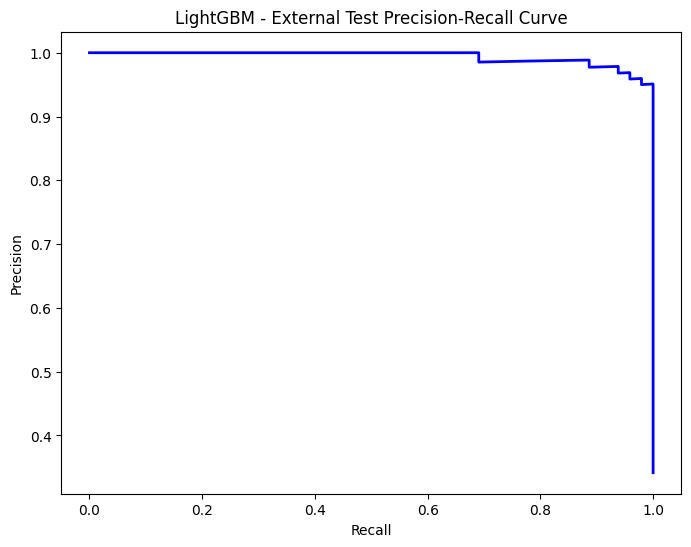



CatBoost - External Test Accuracy: 0.9542
CatBoost - External Test Precision: 0.9375
CatBoost - External Test Recall: 0.9278
CatBoost - External Test F1 Score: 0.9326
CatBoost - External Test AUROC Score: 0.9896
CatBoost - External Test AUROC Confidence Interval: [0.9815 - 0.9964]
CatBoost - External Test Confusion Matrix:
[[181   6]
 [  7  90]]
CatBoost - External Test Classification Report:
              precision    recall  f1-score   support

         0.0       0.96      0.97      0.97       187
         1.0       0.94      0.93      0.93        97

    accuracy                           0.95       284
   macro avg       0.95      0.95      0.95       284
weighted avg       0.95      0.95      0.95       284






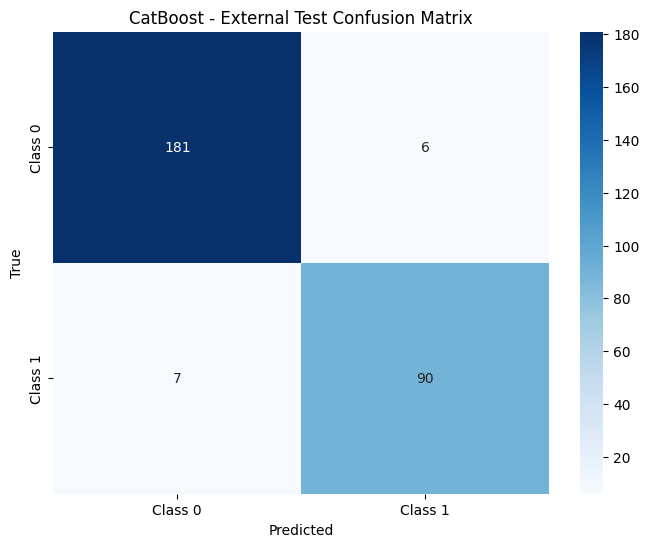

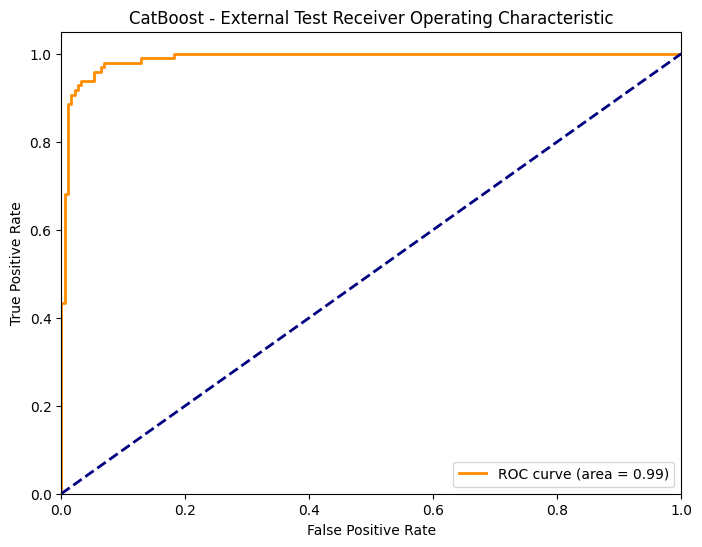

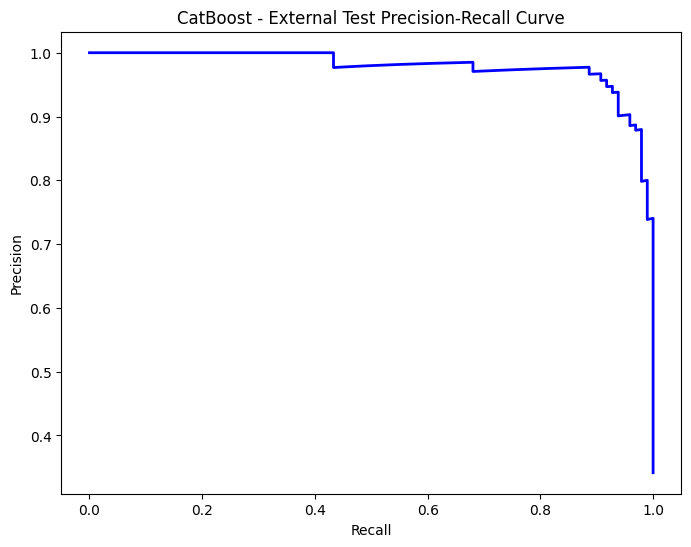

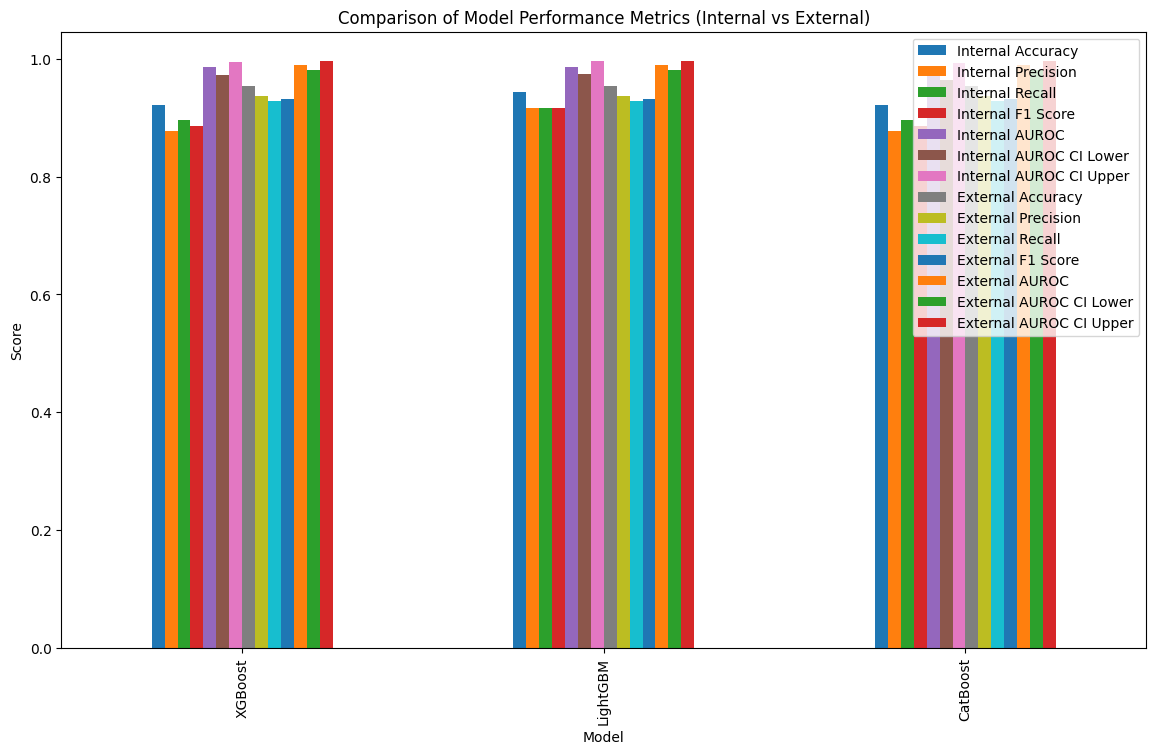

In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, roc_curve, auc,
                             precision_recall_curve)

# Set parameters
n_bootstraps = 1000
rng_seed = 42

def CI(y_true, y_pred, n_bootstraps=n_bootstraps, rng_seed=rng_seed):
    """Calculate confidence interval for ROC AUC score using bootstrapping."""
    bootstrapped_scores = []
    rng = np.random.RandomState(rng_seed)
    for _ in range(n_bootstraps):
        indices = rng.randint(0, len(y_pred), len(y_pred))
        if len(np.unique(y_true[indices])) < 2:
            continue
        score = roc_auc_score(y_true[indices], y_pred[indices])
        bootstrapped_scores.append(score)

    sorted_scores = np.array(bootstrapped_scores)
    sorted_scores.sort()

    confidence_lower = sorted_scores[int(0.05 * len(sorted_scores))]
    confidence_upper = sorted_scores[int(0.95 * len(sorted_scores))]
    return confidence_lower, confidence_upper

# Initialize models
xgb_model = XGBClassifier(n_estimators=100, random_state=10306)
lgbm_model = LGBMClassifier(n_estimators=100, random_state=12300)
catboost_model = CatBoostClassifier(n_estimators=100, random_state=12300, verbose=0)

# Train each model
xgb_model.fit(Xtrain[:, Counts_metas['metas_index'][0:10]], ytrain)
lgbm_model.fit(Xtrain[:, Counts_metas['metas_index'][0:10]], ytrain)
catboost_model.fit(Xtrain[:, Counts_metas['metas_index'][0:10]], ytrain)

# Prepare to store metrics
metrics = {
    "Model": [],
    "Accuracy": [],
    "Precision": [],
    "Recall": [],
    "F1 Score": [],
    "AUROC": [],
    "AUROC CI Lower": [],
    "AUROC CI Upper": []
}

# Predict and evaluate performance on internal test dataset
for model, name in [(xgb_model, "XGBoost"), (lgbm_model, "LightGBM"), (catboost_model, "CatBoost")]:
    pred = model.predict(Xtest[:, Counts_metas['metas_index'][0:10]])
    prob = model.predict_proba(Xtest[:, Counts_metas['metas_index'][0:10]])[:, -1]

    # Calculate metrics
    accuracy = accuracy_score(ytest, pred)
    precision = precision_score(ytest, pred)
    recall = recall_score(ytest, pred)
    f1 = f1_score(ytest, pred)
    auroc = roc_auc_score(ytest, prob)

    # Confidence intervals for ROC AUC
    auroc_ci_lower, auroc_ci_upper = CI(ytest, prob)

    # Store metrics
    metrics["Model"].append(name)
    metrics["Accuracy"].append(accuracy)
    metrics["Precision"].append(precision)
    metrics["Recall"].append(recall)
    metrics["F1 Score"].append(f1)
    metrics["AUROC"].append(auroc)
    metrics["AUROC CI Lower"].append(auroc_ci_lower)
    metrics["AUROC CI Upper"].append(auroc_ci_upper)
    print("\n\n")
    # Print metrics
    print(f"{name} - Accuracy: {accuracy:.4f}")
    print(f"{name} - Precision: {precision:.4f}")
    print(f"{name} - Recall: {recall:.4f}")
    print(f"{name} - F1 Score: {f1:.4f}")
    print(f"{name} - AUROC Score: {auroc:.4f}")
    print(f"{name} - AUROC Confidence Interval: [{auroc_ci_lower:.4f} - {auroc_ci_upper:.4f}]")
    print(f"{name} - Confusion Matrix:\n{confusion_matrix(ytest, pred)}")
    print(f"{name} - Classification Report:\n{classification_report(ytest, pred)}")
    print("\n\n")
    # Plot confusion matrix
    conf_matrix = confusion_matrix(ytest, pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
    plt.title(f'{name} - Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.savefig(f'{name}_confusion_matrix.png')
    plt.show()
    print("\n\n")

    # Plot ROC curve
    fpr, tpr, _ = roc_curve(ytest, prob)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'{name} - Receiver Operating Characteristic')
    plt.legend(loc='lower right')
    plt.savefig(f'{name}_roc_curve.png')
    plt.show()
    print("\n\n")
    # Plot Precision-Recall curve
    precision_vals, recall_vals, _ = precision_recall_curve(ytest, prob)
    plt.figure(figsize=(8, 6))
    plt.plot(recall_vals, precision_vals, color='blue', lw=2)
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'{name} - Precision-Recall Curve')
    plt.savefig(f'{name}_precision_recall_curve.png')
    plt.show()

# Create comparison chart
metrics_df = pd.DataFrame(metrics)
metrics_df.set_index('Model', inplace=True)
metrics_df.plot(kind='bar', figsize=(14, 8))
plt.title('Comparison of Model Performance Metrics')
plt.ylabel('Score')
plt.xlabel('Model')
plt.legend(loc='best')
plt.savefig('model_comparison.png')
plt.show()

####### Using external test dataset to validate the model.

# Load external test data
Xexternal_test = pd.read_excel('Data/Xexternal_test.xlsx', index_col=0)
yexternal_test = pd.read_excel('Data/yexternal_test.xlsx', index_col=0)

# Preprocess external test data
Xexternal_test.drop(['sample_id'], axis=1, inplace=True)
yexternal_test = np.array(yexternal_test.state).astype(np.float32)
Xexternal_test = Xexternal_test.values

print("External test, normal-patients:", np.unique(yexternal_test, return_counts=True))

# Predict and evaluate performance on external dataset
for model, name in [(xgb_model, "XGBoost"), (lgbm_model, "LightGBM"), (catboost_model, "CatBoost")]:
    external_test_pred = model.predict(Xexternal_test[:, Counts_metas['metas_index'][0:10]])
    external_test_prob = model.predict_proba(Xexternal_test[:, Counts_metas['metas_index'][0:10]])[:, -1]

    # Calculate metrics
    accuracy_ext = accuracy_score(yexternal_test, external_test_pred)
    precision_ext = precision_score(yexternal_test, external_test_pred)
    recall_ext = recall_score(yexternal_test, external_test_pred)
    f1_ext = f1_score(yexternal_test, external_test_pred)
    auroc_ext = roc_auc_score(yexternal_test, external_test_prob)

    # Confidence intervals for ROC AUC
    auroc_ci_lower_ext, auroc_ci_upper_ext = CI(yexternal_test, external_test_prob)

    # Print metrics
    print(f"\n\n{name} - External Test Accuracy: {accuracy_ext:.4f}")
    print(f"{name} - External Test Precision: {precision_ext:.4f}")
    print(f"{name} - External Test Recall: {recall_ext:.4f}")
    print(f"{name} - External Test F1 Score: {f1_ext:.4f}")
    print(f"{name} - External Test AUROC Score: {auroc_ext:.4f}")

    print(f"{name} - External Test AUROC Confidence Interval: [{auroc_ci_lower_ext:.4f} - {auroc_ci_upper_ext:.4f}]")
    print(f"{name} - External Test Confusion Matrix:\n{confusion_matrix(yexternal_test, external_test_pred)}")
    print(f"{name} - External Test Classification Report:\n{classification_report(yexternal_test, external_test_pred)}")
    print("\n\n")

    # Plot confusion matrix for external test data
    conf_matrix_ext = confusion_matrix(yexternal_test, external_test_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix_ext, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
    plt.title(f'{name} - External Test Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.savefig(f'{name}_external_test_confusion_matrix.png')
    plt.show()
    print("\n\n")

    # Plot ROC curve for external test data
    fpr_ext, tpr_ext, _ = roc_curve(yexternal_test, external_test_prob)
    roc_auc_ext = auc(fpr_ext, tpr_ext)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr_ext, tpr_ext, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_ext:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'{name} - External Test Receiver Operating Characteristic')
    plt.legend(loc='lower right')
    plt.savefig(f'{name}_external_test_roc_curve.png')
    plt.show()
    print("\n\n")

    # Plot Precision-Recall curve for external test data
    precision_vals_ext, recall_vals_ext, _ = precision_recall_curve(yexternal_test, external_test_prob)
    plt.figure(figsize=(8, 6))
    plt.plot(recall_vals_ext, precision_vals_ext, color='blue', lw=2)
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'{name} - External Test Precision-Recall Curve')
    plt.savefig(f'{name}_external_test_precision_recall_curve.png')
    plt.show()

# Optionally, you can compare metrics on both internal and external datasets
internal_metrics_df = pd.DataFrame(metrics)
internal_metrics_df.set_index('Model', inplace=True)
internal_metrics_df.columns = [f'Internal {col}' for col in internal_metrics_df.columns]

# Create comparison for external dataset
external_metrics = {
    "Model": [],
    "Accuracy": [],
    "Precision": [],
    "Recall": [],
    "F1 Score": [],
    "AUROC": [],
    "AUROC CI Lower": [],
    "AUROC CI Upper": []
}

for model, name in [(xgb_model, "XGBoost"), (lgbm_model, "LightGBM"), (catboost_model, "CatBoost")]:
    # Append external metrics to the dataframe
    external_metrics["Model"].append(name)
    external_metrics["Accuracy"].append(accuracy_ext)
    external_metrics["Precision"].append(precision_ext)
    external_metrics["Recall"].append(recall_ext)
    external_metrics["F1 Score"].append(f1_ext)
    external_metrics["AUROC"].append(auroc_ext)
    external_metrics["AUROC CI Lower"].append(auroc_ci_lower_ext)
    external_metrics["AUROC CI Upper"].append(auroc_ci_upper_ext)

external_metrics_df = pd.DataFrame(external_metrics)
external_metrics_df.set_index('Model', inplace=True)
external_metrics_df.columns = [f'External {col}' for col in external_metrics_df.columns]

# Combine internal and external metrics for comparison
comparison_df = pd.concat([internal_metrics_df, external_metrics_df], axis=1)

# Plot combined comparison chart
comparison_df.plot(kind='bar', figsize=(14, 8))
plt.title('Comparison of Model Performance Metrics (Internal vs External)')
plt.ylabel('Score')
plt.xlabel('Model')
plt.legend(loc='best')
plt.savefig('model_comparison_internal_vs_external.png')
plt.show()
